# `Malaria Cell Images Dataset` EDA pre GAN

Cieľ: pripraviť prehľad datasetu `cell_images` pre generovanie buniek pomocou GAN. Dataset obsahuje dve triedy:

- `Parasitized`
- `Uninfected`

Notebook robí základné EDA, vizualizuje distribúciu veľkostí a ukazuje náhodné ukážky obrázkov.

In [4]:
from pathlib import Path
from collections import Counter
import random

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Dataset a helper funkcie

Najprv si načítame cesty a nastavíme pár pomocných funkcií. Pri EDA ignorujeme neobrázkové súbory ako `Thumbs.db`.

In [5]:
ROOT = Path('cell_images')
CLASSES = ['Parasitized', 'Uninfected']
VALID_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.webp'}

def load_rgb(path: Path):
    if path.suffix.lower() not in VALID_EXTENSIONS:
        return None
    try:
        with Image.open(path) as img:
            return img.convert('RGB').copy()
    except Exception:
        return None

def class_paths(root: Path):
    return {
        cls: sorted(p for p in (root / cls).iterdir() if p.is_file())
        for cls in CLASSES
    }

paths = class_paths(ROOT)
for cls in CLASSES:
    print(cls, len(paths[cls]))

Parasitized 13779
Uninfected 13779


## 2. Základná štatistika

Spočítame počet validných obrázkov, neplatné súbory, rozsah rozlíšení a základné farebné štatistiky.

In [6]:
def class_stats(paths_for_class):
    sizes = Counter()
    mode_counts = Counter()
    invalid = []
    widths = []
    heights = []
    valid = []

    for p in paths_for_class:
        img = load_rgb(p)
        if img is None:
            invalid.append(p.name)
            continue
        valid.append(p)
        sizes[img.size] += 1
        mode_counts['RGB'] += 1
        widths.append(img.size[0])
        heights.append(img.size[1])

    sample = random.Random(42).sample(valid, min(200, len(valid)))
    total = np.zeros(3, dtype=np.float64)
    total_sq = np.zeros(3, dtype=np.float64)
    pixels = 0
    for p in sample:
        img = load_rgb(p)
        if img is None:
            continue
        arr = np.asarray(img, dtype=np.float32) / 255.0
        flat = arr.reshape(-1, 3)
        total += flat.sum(axis=0)
        total_sq += np.square(flat).sum(axis=0)
        pixels += flat.shape[0]

    mean = total / pixels
    var = np.maximum(total_sq / pixels - np.square(mean), 0.0)
    std = np.sqrt(var)

    return {
        'total_files': len(paths_for_class),
        'valid_images': len(valid),
        'invalid_files': invalid,
        'unique_sizes': len(sizes),
        'size_range': (min(widths), max(widths), min(heights), max(heights)),
        'top_sizes': sizes.most_common(10),
        'mean_rgb': mean,
        'std_rgb': std,
    }

stats = {cls: class_stats(paths[cls]) for cls in CLASSES}
total_valid = sum(stats[cls]['valid_images'] for cls in CLASSES)
total_invalid = sum(len(stats[cls]['invalid_files']) for cls in CLASSES)
balance = stats['Parasitized']['valid_images'] / stats['Uninfected']['valid_images']

print('Valid images:', total_valid)
print('Invalid files:', total_invalid)
print('Class balance ratio:', round(balance, 4))
for cls in CLASSES:
    s = stats[cls]
    print('\n', cls)
    print('  valid:', s['valid_images'])
    print('  invalid:', s['invalid_files'])
    print('  unique sizes:', s['unique_sizes'])
    print('  size range:', s['size_range'])
    print('  mean RGB:', np.round(s['mean_rgb'], 4))
    print('  std RGB:', np.round(s['std_rgb'], 4))

Valid images: 27558
Invalid files: 0
Class balance ratio: 1.0

 Parasitized
  valid: 13779
  invalid: []
  unique sizes: 1402
  size range: (46, 394, 40, 385)
  mean RGB: [0.5216 0.3982 0.4283]
  std RGB: [0.3533 0.2754 0.2896]

 Uninfected
  valid: 13779
  invalid: []
  unique sizes: 1207
  size range: (49, 247, 49, 235)
  mean RGB: [0.5258 0.4378 0.4603]
  std RGB: [0.3394 0.2818 0.2958]


## 3. Duplicity

Skontrolujeme presné duplicity podľa obsahu súborov. To je užitočné pred tréningom, aby si nezavadzal redundantné vzorky do datasetu.

In [7]:
import hashlib
from collections import defaultdict

def file_hash(path):
    h = hashlib.md5()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

hash_to_entries = defaultdict(list)
for cls in CLASSES:
    for p in paths[cls]:
        if load_rgb(p) is None:
            continue
        hash_to_entries[file_hash(p)].append((cls, p.name))

duplicate_groups = [entries for entries in hash_to_entries.values() if len(entries) > 1]
cross_class_groups = [
    entries for entries in duplicate_groups
    if len({cls for cls, _ in entries}) > 1
]

print('Duplicate groups:', len(duplicate_groups))
print('Cross-class duplicate groups:', len(cross_class_groups))
for entries in duplicate_groups[:10]:
    print(entries)


Duplicate groups: 0
Cross-class duplicate groups: 0


## 4. Počet obrázkov v triedach

Triedy sú prakticky vyvážené, čo je pre GAN výborné.

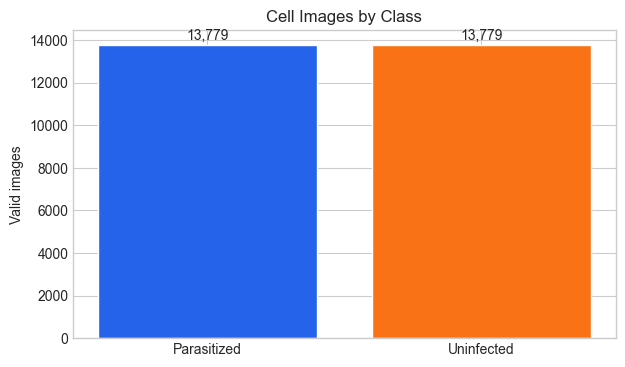

In [8]:
labels = CLASSES
counts = [stats[c]['valid_images'] for c in labels]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts, color=['#2563eb', '#f97316'])
ax.set_title('Cell Images by Class')
ax.set_ylabel('Valid images')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 100, f'{count:,}', ha='center', va='bottom')
plt.show()

## 5. Distribúcia rozlíšení

Dataset obsahuje veľa rôznych rozmerov, preto bude treba fixný resize pred tréningom GAN.

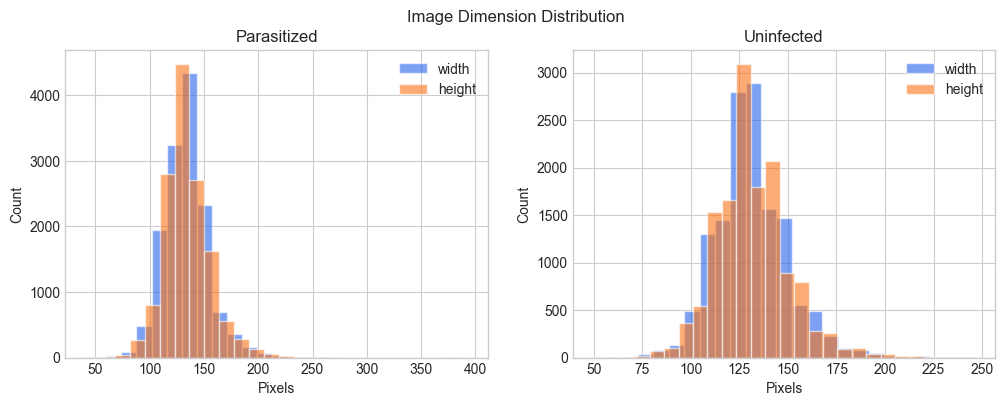

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cls in zip(axes, CLASSES):
    widths = []
    heights = []
    for p in paths[cls]:
        if p.suffix.lower() not in VALID_EXTENSIONS:
            continue
        try:
            with Image.open(p) as img:
                widths.append(img.size[0])
                heights.append(img.size[1])
        except Exception:
            pass
    ax.hist(widths, bins=25, alpha=0.6, label='width', color='#2563eb')
    ax.hist(heights, bins=25, alpha=0.6, label='height', color='#f97316')
    ax.set_title(cls)
    ax.set_xlabel('Pixels')
    ax.set_ylabel('Count')
    ax.legend()
plt.suptitle('Image Dimension Distribution')
plt.show()

## 6. Najčastejšie rozmery

Väčšina obrázkov sa sústreďuje okolo podobných veľkostí, ale nie je to striktne jednotné.

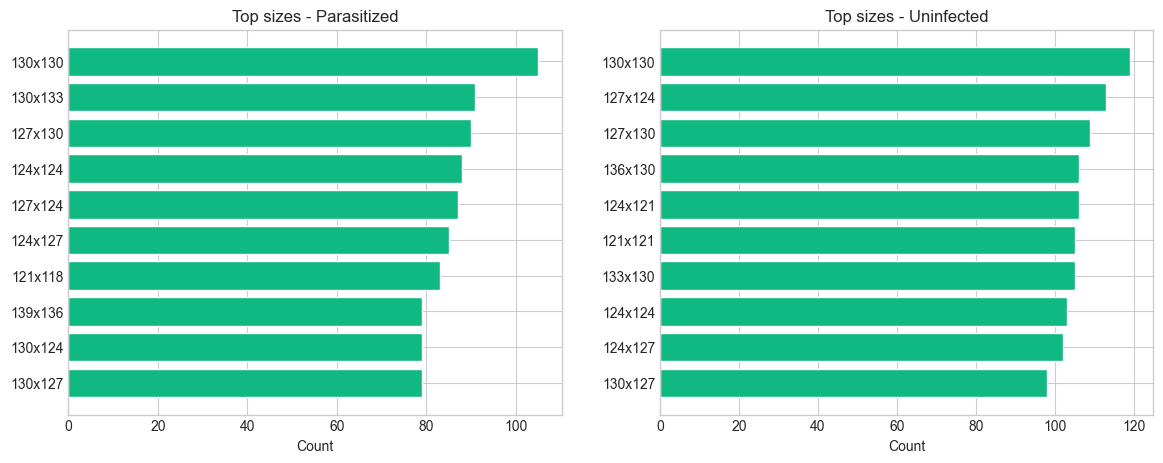

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cls in zip(axes, CLASSES):
    top = stats[cls]['top_sizes'][:10]
    labels = [f'{w}x{h}' for (w, h), _ in top]
    values = [count for _, count in top]
    ax.barh(labels[::-1], values[::-1], color='#10b981')
    ax.set_title(f'Top sizes - {cls}')
    ax.set_xlabel('Count')
plt.show()

## 7. Náhodné ukážky

Na prvý pohľad vyzerajú bunky už dobre orezané. Pozadie je prevažne tmavé a bunky sú v strede, čo je dobré pre generatívny model.

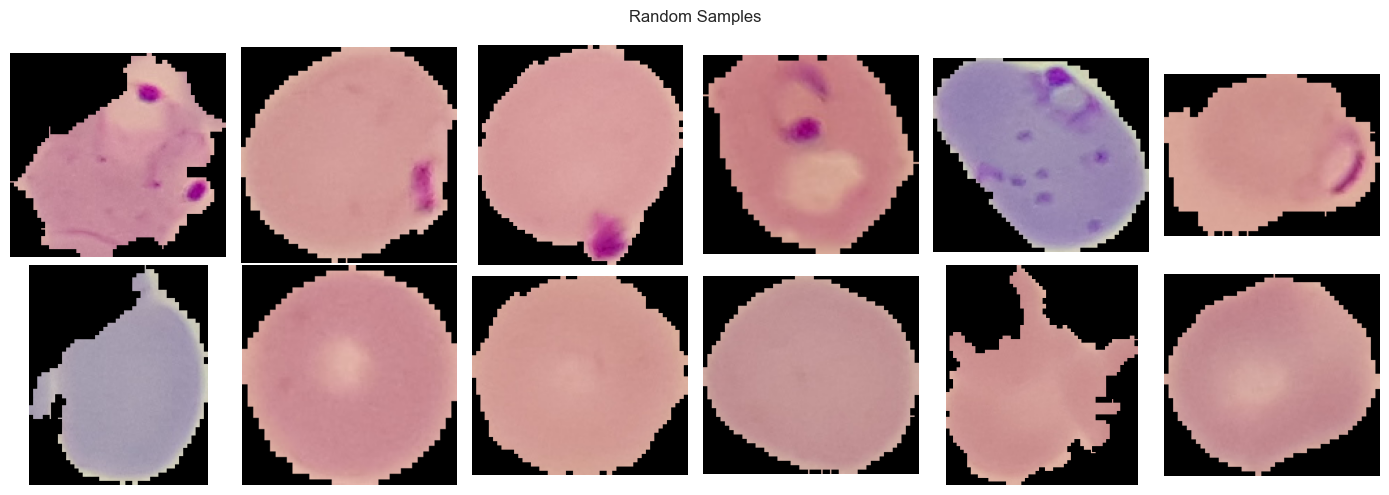

In [11]:
rng = random.Random(42)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for row, cls in enumerate(CLASSES):
    candidates = [p for p in paths[cls] if load_rgb(p) is not None]
    picks = candidates if len(candidates) <= 6 else rng.sample(candidates, 6)
    for col in range(6):
        ax = axes[row, col]
        ax.axis('off')
        if col < len(picks):
            ax.imshow(load_rgb(picks[col]))
    axes[row, 0].set_ylabel(cls, rotation=0, labelpad=40, va='center', fontsize=11)
plt.suptitle('Random Samples')
plt.tight_layout()
plt.show()

## 8. Formáty a režimy

Najprv overíme, v akom formáte sú súbory na disku a v akom image mode sa načítajú. Až potom dáva zmysel robiť RGB analýzu.

In [12]:
def format_and_mode_stats(paths_by_class):
    file_exts = Counter()
    pil_formats = Counter()
    modes = Counter()
    invalid = []

    for cls in CLASSES:
        for p in paths_by_class[cls]:
            file_exts[p.suffix.lower()] += 1
            img = load_rgb(p)
            if img is None:
                invalid.append(p.name)
                continue
            try:
                with Image.open(p) as raw:
                    pil_formats[raw.format or 'UNKNOWN'] += 1
                    modes[raw.mode] += 1
            except Exception:
                invalid.append(p.name)

    return file_exts, pil_formats, modes, invalid

file_exts, pil_formats, modes, invalid = format_and_mode_stats(paths)
print('File extensions:', dict(file_exts))
print('PIL formats:', dict(pil_formats))
print('Image modes:', dict(modes))
print('Invalid files:', invalid)
assert modes == Counter({'RGB': sum(stats[c]['valid_images'] for c in CLASSES)})
assert pil_formats == Counter({'PNG': sum(stats[c]['valid_images'] for c in CLASSES)})

File extensions: {'.png': 27558}
PIL formats: {'PNG': 27558}
Image modes: {'RGB': 27558}
Invalid files: []


## 9. Intenzity kanálov

Keďže sme overili, že validné obrázky sú RGB PNG súbory, pozrieme sa len na priemerné intenzity farebných kanálov pre obe triedy.

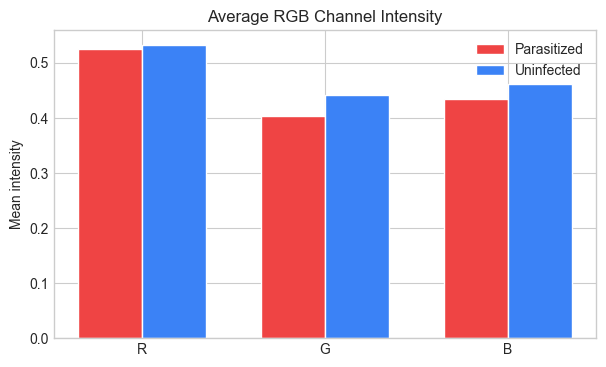

Parasitized [0.525  0.4037 0.4344]
Uninfected [0.5324 0.4407 0.4622]


In [13]:
def channel_means(image_paths):
    total = np.zeros(3, dtype=np.float64)
    total_pixels = 0
    for p in image_paths:
        img = load_rgb(p)
        if img is None:
            continue
        arr = np.asarray(img, dtype=np.float32) / 255.0
        flat = arr.reshape(-1, 3)
        total += flat.sum(axis=0)
        total_pixels += flat.shape[0]
    return total / total_pixels

channel_summary = {
    cls: channel_means(paths[cls])
    for cls in CLASSES
}

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
width = 0.35
ax.bar(x - width / 2, channel_summary['Parasitized'], width, label='Parasitized', color='#ef4444')
ax.bar(x + width / 2, channel_summary['Uninfected'], width, label='Uninfected', color='#3b82f6')
ax.set_xticks(x)
ax.set_xticklabels(['R', 'G', 'B'])
ax.set_ylabel('Mean intensity')
ax.set_title('Average RGB Channel Intensity')
ax.legend()
plt.show()

for cls, values in channel_summary.items():
    print(cls, np.round(values, 4))

## 10. Aspect ratio a jas

Okrem samotných rozmerov je užitočné pozrieť sa na pomer strán a priemerný jas obrázkov.

Parasitized
  aspect ratio mean: 1.006
  aspect ratio std: 0.1505
  brightness mean: 0.457
  brightness std: 0.0461
Uninfected
  aspect ratio mean: 1.0085
  aspect ratio std: 0.1438
  brightness mean: 0.4806
  brightness std: 0.0445


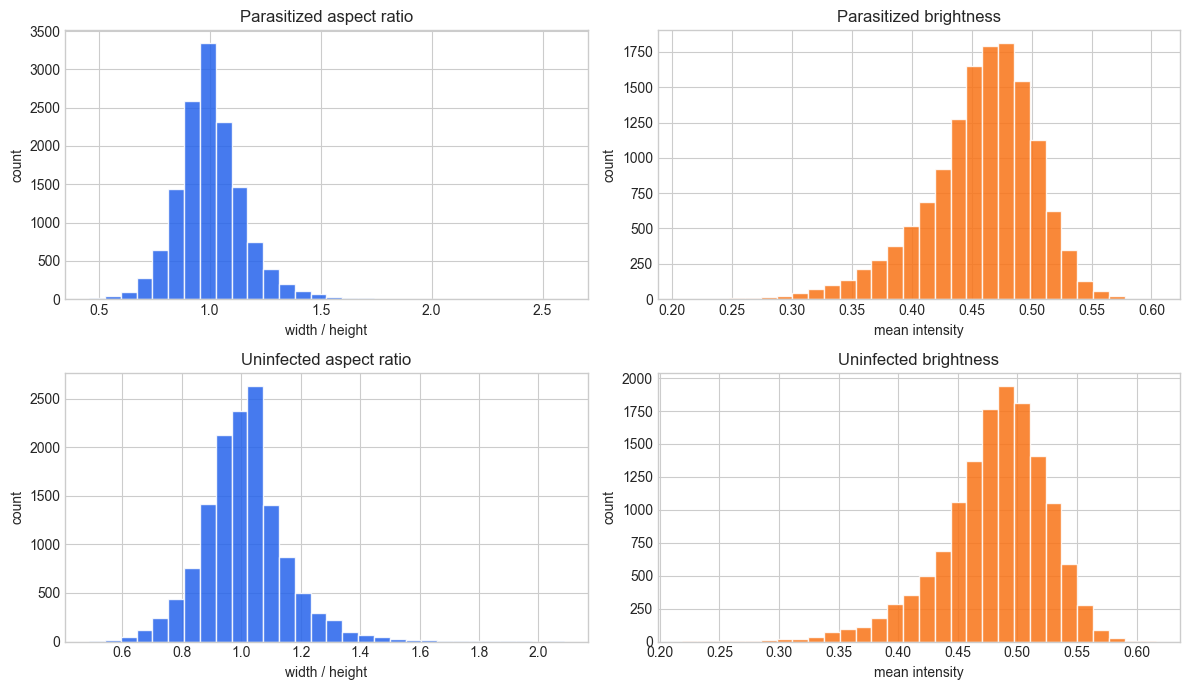

In [14]:
def image_shape_metrics(paths_for_class):
    aspect_ratios = []
    brightness = []
    for p in paths_for_class:
        img = load_rgb(p)
        if img is None:
            continue
        arr = np.asarray(img, dtype=np.float32) / 255.0
        w, h = img.size
        aspect_ratios.append(w / h)
        brightness.append(float(arr.mean()))
    return np.array(aspect_ratios), np.array(brightness)

metrics = {cls: image_shape_metrics(paths[cls]) for cls in CLASSES}
for cls, (ratios, bright) in metrics.items():
    print(cls)
    print('  aspect ratio mean:', round(float(ratios.mean()), 4))
    print('  aspect ratio std:', round(float(ratios.std()), 4))
    print('  brightness mean:', round(float(bright.mean()), 4))
    print('  brightness std:', round(float(bright.std()), 4))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, cls in enumerate(CLASSES):
    ratios, bright = metrics[cls]
    axes[row, 0].hist(ratios, bins=30, color='#2563eb', alpha=0.85)
    axes[row, 0].set_title(f'{cls} aspect ratio')
    axes[row, 0].set_xlabel('width / height')
    axes[row, 0].set_ylabel('count')
    axes[row, 1].hist(bright, bins=30, color='#f97316', alpha=0.85)
    axes[row, 1].set_title(f'{cls} brightness')
    axes[row, 1].set_xlabel('mean intensity')
    axes[row, 1].set_ylabel('count')
plt.tight_layout()
plt.show()


## 11. Preprocessing pipeline

Toto je spoločná prípravná vrstva pre všetky ďalšie experimenty.

Robíme tu:
- validáciu ciest a vyradenie neplatných súborov
- načítanie iba RGB obrázkov
- resize na fixný rozmer `128x128`
- konverziu do `float32`
- normalizáciu pixelov do rozsahu `[-1, 1]`
- batch loader pre tréning GAN-u
- balanced split na `train / val / test`
- zachovanie vyváženosti tried `Parasitized` a `Uninfected`

Split je približne:
- `train`: `80%`
- `val`: `10%`
- `test`: `10%`


In [15]:
try:
    RESAMPLE = Image.Resampling.BILINEAR
except AttributeError:
    RESAMPLE = Image.BILINEAR

TARGET_SIZE = (128, 128)
CHANNELS = 3
NORMALIZE_RANGE = (-1.0, 1.0)
RNG = np.random.default_rng(42)

def list_valid_images(class_paths):
    valid = []
    invalid = []
    for p in class_paths:
        img = load_rgb(p)
        if img is None:
            invalid.append(p)
        else:
            valid.append(p)
    return valid, invalid

def load_preprocessed_image(path, target_size=TARGET_SIZE, normalize=True):
    img = load_rgb(path)
    if img is None:
        return None
    arr = np.asarray(img.resize(target_size, RESAMPLE), dtype=np.float32) / 255.0
    if normalize:
        arr = arr * 2.0 - 1.0
    return arr

def batch_images(image_paths, batch_size=32, target_size=TARGET_SIZE, shuffle=True, normalize=True):
    paths_local = list(image_paths)
    if shuffle:
        RNG.shuffle(paths_local)
    for start in range(0, len(paths_local), batch_size):
        batch_paths = paths_local[start:start + batch_size]
        batch = []
        for p in batch_paths:
            arr = load_preprocessed_image(p, target_size=target_size, normalize=normalize)
            if arr is not None:
                batch.append(arr)
        if batch:
            yield np.stack(batch, axis=0)

def balanced_split(paths_by_class, val_ratio=0.1, test_ratio=0.1, seed=42):
    rng = np.random.default_rng(seed)
    splits = {"train": {}, "val": {}, "test": {}}
    for cls, cls_paths in paths_by_class.items():
        items = np.array(cls_paths, dtype=object)
        rng.shuffle(items)
        n = len(items)
        n_test = int(n * test_ratio)
        n_val = int(n * val_ratio)
        splits["test"][cls] = items[:n_test].tolist()
        splits["val"][cls] = items[n_test:n_test + n_val].tolist()
        splits["train"][cls] = items[n_test + n_val:].tolist()
    return splits

valid_paths = {}
invalid_paths = {}
for cls in CLASSES:
    valid_paths[cls], invalid_paths[cls] = list_valid_images(paths[cls])

splits = balanced_split(valid_paths, val_ratio=0.1, test_ratio=0.1, seed=42)

print('Pipeline settings:')
print('  TARGET_SIZE:', TARGET_SIZE)
print('  CHANNELS:', CHANNELS)
print('  NORMALIZE_RANGE:', NORMALIZE_RANGE)
print('  batch_images(...) -> numpy batches ready for GAN training')

print('Split sizes:')
for split_name in ['train', 'val', 'test']:
    print(f'  {split_name}:')
    for cls in CLASSES:
        print(f'    {cls}: {len(splits[split_name][cls])}')

print('Invalid files kept out of training:')
for cls in CLASSES:
    print(f'  {cls}: {len(invalid_paths[cls])}')


Pipeline settings:
  TARGET_SIZE: (128, 128)
  CHANNELS: 3
  NORMALIZE_RANGE: (-1.0, 1.0)
  batch_images(...) -> numpy batches ready for GAN training
Split sizes:
  train:
    Parasitized: 11025
    Uninfected: 11025
  val:
    Parasitized: 1377
    Uninfected: 1377
  test:
    Parasitized: 1377
    Uninfected: 1377
Invalid files kept out of training:
  Parasitized: 0
  Uninfected: 0


## 12. Treningove prostredie a logovanie

V dalsich bunkach pridame rovnaku experimentacnu kostru ako v `Animal10.ipynb`, ale pre generativne modely. Cielom je mat vsetky hlavne parametre na jednom mieste, jednotny sposob logovania do `wandb` a konzistentne ukladanie checkpointov.

Kazdy checkpoint ulozi:
- stav generatora aj diskriminatora,
- kompletnu konfiguraciu experimentu,
- fixny `noise` tensor pre porovnanie,
- sample grid vygenerovany z toho isteho latentneho vstupu.


In [16]:
import copy
import importlib
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.optim as optim
import wandb

from PIL import Image
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from dotenv import load_dotenv
import malaria_gan_dataset

importlib.reload(malaria_gan_dataset)
from malaria_gan_dataset import MalariaGanDataset


load_dotenv()

WANDB_API_KEY = os.getenv('WANDB_API_KEY')
if WANDB_API_KEY:
    os.environ['WANDB_API_KEY'] = WANDB_API_KEY

wandb.login(key=WANDB_API_KEY, relogin=False) if WANDB_API_KEY else wandb.login(anonymous='allow', relogin=False)


if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print('Device:', DEVICE)

CHECKPOINT_ROOT = Path('checkpoints/gan')
for directory in [CHECKPOINT_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)


/Users/romankosik/PycharmProjects/Neuronove_siete/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/romankosik/.netrc
wandb: Currently logged in as: xkosik (xkosik-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Device: mps


## 13. Definicia konfiguracie a experimentov

Podobne ako pri klasifikacii budeme mat jeden spolocny zaklad a jednotlive experimenty budu menit len to, co je skutocne potrebne. Prve behy ostavaju plne `from scratch` v PyTorchi a az neskor sa da na tento ramec jednoducho doplnit perceptual loss alebo pretrained backbone.


In [17]:
GAN_BASE_CONFIG = {
    'project': 'NSIETE_GAN_Malaria',
    'entity': 'lui-vitarius-slovak-university-of-technology',
    'seed': 42,
    'data': {
        'selected_classes': CLASSES,
        'target_size': 128,
        'batch_size': 128,
        'num_workers': 8,
        'shuffle': True,
        'drop_last': True,
        'horizontal_flip': True,
    },
    'model': {
        'image_channels': 3,
        'latent_dim': 128,
        'base_channels': 64,
        'generator_batchnorm': True,
        'discriminator_batchnorm': True,
        'discriminator_dropout': 0.0,
        'leaky_relu_slope': 0.2,
        'conditional': True,
        'num_classes': len(CLASSES),
        'class_names': CLASSES,
        'generator_condition_mode': 'concat_input',
        'condition_channels_per_stage': [16, 16, 8, 8, 4, 4],
        'discriminator_condition_mode': 'concat_map',
    },
    'optimization': {
        'gan_type': 'vanilla',
        'g_lr': 2e-4,
        'd_lr': 2e-4,
        'betas': (0.5, 0.999),
        'weight_decay': 0.0,
        'n_critic': 1,
        'real_label': 0.9,
        'fake_label': 0.0,
        'label_noise': 0.0,
        'gradient_penalty_lambda': 10.0,
    },
    'trainer': {
        'epochs': 30,
        'max_train_batches': None,
        'log_every_steps': 50,
        'checkpoint_every': 5,
        'num_fixed_samples': 16,
    },
}


In [18]:

def deep_update(base, updates):
    merged = copy.deepcopy(base)
    for key, value in updates.items():
        if isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key] = deep_update(merged[key], value)
        else:
            merged[key] = value
    return merged



def make_experiment(run_name, description, **updates):
    cfg = deep_update(GAN_BASE_CONFIG, updates)
    cfg['run_name'] = run_name
    cfg['description'] = description
    return cfg


In [19]:

EXPERIMENTS = [
    make_experiment(
        run_name='basic_gan_scratch',
        description='Zakladny GAN od nuly so sigmoid diskriminatorom a BCE loss.',
        model={
            'base_channels': 32,
            'generator_batchnorm': False,
            'discriminator_batchnorm': False,
        },
        trainer={
            'epochs': 60,
            'checkpoint_every': 5,
        },
    ),
    make_experiment(
        run_name='dcgan_scratch',
        description='Silnejsi DCGAN z nulovej inicializacie s batch norm a jemnym label smoothingom.',
        model={
            'base_channels': 64,
            'generator_batchnorm': True,
            'discriminator_batchnorm': True,
        },
        optimization={
            'gan_type': 'vanilla',
            'real_label': 0.9,
            'fake_label': 0.0,
            'label_noise': 0.05,
        },
        trainer={
            'epochs': 80,
            'checkpoint_every': 5,
        },
    ),
    make_experiment(
        run_name='lsgan_scratch',
        description='Least-Squares GAN ako stabilnejsia alternativa ku klasickemu BCE GAN-u.',
        model={
            'base_channels': 64,
            'generator_batchnorm': True,
            'discriminator_batchnorm': True,
        },
        optimization={
            'gan_type': 'lsgan',
        },
        trainer={
            'epochs': 80,
            'checkpoint_every': 5,
        },
    ),
    make_experiment(
        run_name='wgan_gp_scratch',
        description='Conditional WGAN-GP baseline s critic update 5x na batch a gradient penalty pre lepsiu stabilitu.',
        model={
            'base_channels': 64,
            'generator_batchnorm': True,
            'discriminator_batchnorm': False,
            'discriminator_dropout': 0.0,
        },
        optimization={
            'gan_type': 'wgan-gp',
            'n_critic': 5,
            'gradient_penalty_lambda': 10.0,
            'd_lr': 1e-4,
            'g_lr': 1e-4,
            'betas': (0.0, 0.9),
        },
        trainer={
            'epochs': 120,
            'checkpoint_every': 5,
        },
    ),
    make_experiment(
        run_name='wgan_gp_cond_projection_critic',
        description='Conditional WGAN-GP s projection discriminatorom, kde critic porovnava feature reprezentaciu obrazu priamo s embeddingom triedy.',
        model={
            'base_channels': 64,
            'generator_batchnorm': True,
            'discriminator_batchnorm': False,
            'discriminator_dropout': 0.0,
            'discriminator_condition_mode': 'projection',
        },
        optimization={
            'gan_type': 'wgan-gp',
            'n_critic': 5,
            'gradient_penalty_lambda': 10.0,
            'd_lr': 1e-4,
            'g_lr': 1e-4,
            'betas': (0.0, 0.9),
        },
        trainer={
            'epochs': 60,
            'checkpoint_every': 5,
        },
    ),
    make_experiment(
        run_name='wgan_gp_cond_inject_all_layers',
        description='Conditional WGAN-GP, kde sa triedna informacia pridava do kazdej generativnej vrstvy a nie iba do prveho latentneho vstupu.',
        model={
            'base_channels': 64,
            'generator_batchnorm': True,
            'discriminator_batchnorm': False,
            'discriminator_dropout': 0.0,
            'generator_condition_mode': 'inject_all',
            'condition_channels_per_stage': [16, 16, 8, 8, 4, 4],
        },
        optimization={
            'gan_type': 'wgan-gp',
            'n_critic': 5,
            'gradient_penalty_lambda': 10.0,
            'd_lr': 1e-4,
            'g_lr': 1e-4,
            'betas': (0.0, 0.9),
        },
        trainer={
            'epochs': 60,
            'checkpoint_every': 5,
        },
    ),
]

experiment_overview = pd.DataFrame([
    {
        'run_name': cfg['run_name'],
        'gan_type': cfg['optimization']['gan_type'],
        'epochs': cfg['trainer']['epochs'],
        'batch_size': cfg['data']['batch_size'],
        'latent_dim': cfg['model']['latent_dim'],
        'base_channels': cfg['model']['base_channels'],
        'conditional': cfg['model'].get('conditional', False),
        'generator_condition_mode': cfg['model'].get('generator_condition_mode', 'concat_input'),
        'discriminator_condition_mode': cfg['model'].get('discriminator_condition_mode', 'concat_map'),
        'n_critic': cfg['optimization']['n_critic'],
        'description': cfg['description'],
    }
    for cfg in EXPERIMENTS
])

experiment_overview


,run_name,gan_type,epochs,batch_size,latent_dim,base_channels,conditional,generator_condition_mode,discriminator_condition_mode,n_critic,description
0,basic_gan_scratch,vanilla,60,128,128,32,True,concat_input,concat_map,1,Zakladny GAN od nuly so sigmoid diskriminatoro...
1,dcgan_scratch,vanilla,80,128,128,64,True,concat_input,concat_map,1,Silnejsi DCGAN z nulovej inicializacie s batch...
2,lsgan_scratch,lsgan,80,128,128,64,True,concat_input,concat_map,1,Least-Squares GAN ako stabilnejsia alternativa...
3,wgan_gp_scratch,wgan-gp,120,128,128,64,True,concat_input,concat_map,5,Conditional WGAN-GP baseline s critic update 5...
4,wgan_gp_cond_projection_critic,wgan-gp,60,128,128,64,True,concat_input,projection,5,Conditional WGAN-GP s projection discriminator...
5,wgan_gp_cond_inject_all_layers,wgan-gp,60,128,128,64,True,inject_all,concat_map,5,"Conditional WGAN-GP, kde sa triedna informacia..."


### Prehlad experimentov

- `basic_gan_scratch`: najjednoduchsia referencia, aby sme mali jasny baseline bez stabilizacnych trikov.
- `dcgan_scratch`: rovnaky problem, ale s DCGAN stylom architektury a jemnym smoothingom labelov.
- `lsgan_scratch`: meni sa hlavne cielova funkcia, co casto pomaha so stabilitou treningu.
- `wgan_gp_scratch`: silny conditional WGAN-GP baseline, od ktoreho sa odpichuju dalsie conditional varianty.
- `wgan_gp_cond_projection_critic`: critic uz nedostava label ako extra obrazkovy kanal, ale cez projection score porovnava feature reprezentaciu obrazu priamo s embeddingom triedy. Je to silna zmena v conditional mechanizme bez vacsich narokov na compute.
- `wgan_gp_cond_inject_all_layers`: triedna informacia vstupuje do kazdej generativnej vrstvy, takze podmienka nema sancu "zaniknut" po prvom bloku a generator ju nesie az do vysledneho obrazu.

Povodne experimenty teda ostavaju zachovane a nove conditional WGAN-GP varianty su len pridane navyse. Vsetky zdielaju rovnaky datovy pipeline, fixny latentny vstup pre checkpoint samples aj jednotny zapis do `wandb`.


In [20]:
def flatten_split_items(split_name, selected_classes=None):
    selected_classes = selected_classes or CLASSES
    items = []
    for class_id, cls in enumerate(selected_classes):
        items.extend((path, class_id) for path in splits[split_name][cls])
    return items



def build_gan_dataloader(config):
    data_cfg = config['data']
    items = flatten_split_items('train', data_cfg.get('selected_classes'))
    image_paths = [path for path, _ in items]
    labels = [label for _, label in items]
    dataset = MalariaGanDataset(
        image_paths=image_paths,
        labels=labels,
        target_size=data_cfg['target_size'],
        horizontal_flip=data_cfg.get('horizontal_flip', True),
    )
    num_workers = data_cfg.get('num_workers', 0)
    loader_kwargs = {
        'batch_size': data_cfg['batch_size'],
        'shuffle': data_cfg.get('shuffle', True),
        'num_workers': num_workers,
        'drop_last': data_cfg.get('drop_last', True),
        'pin_memory': torch.cuda.is_available(),
    }
    if num_workers > 0:
        loader_kwargs.update({
            'persistent_workers': True,
            'prefetch_factor': 2,
        })
    loader = DataLoader(dataset, **loader_kwargs)
    return dataset, loader



def denormalize_tensor(images):
    return images.detach().cpu().clamp(-1.0, 1.0).add(1.0).div(2.0)



def make_image_grid(images, nrow=4):
    images = denormalize_tensor(images)
    batch, channels, height, width = images.shape
    nrow = max(1, min(nrow, batch))
    ncol = math.ceil(batch / nrow)
    grid = torch.zeros(channels, ncol * height, nrow * width)
    for idx, image in enumerate(images):
        row = idx // nrow
        col = idx % nrow
        grid[:, row * height:(row + 1) * height, col * width:(col + 1) * width] = image
    return grid



def save_image_grid(images, path, nrow=4):
    grid = make_image_grid(images, nrow=nrow)
    array = (grid.permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
    Image.fromarray(array).save(path)
    return path


preview_dataset, preview_loader = build_gan_dataloader(EXPERIMENTS[0])
preview_images, preview_labels = next(iter(preview_loader))
print('Train images prepared for GAN:', len(preview_dataset))
print('One batch image shape:', tuple(preview_images.shape))
print('One batch label shape:', tuple(preview_labels.shape))
print('Label ids in batch:', sorted(preview_labels.unique().tolist()))
print('Pixel range:', float(preview_images.min()), float(preview_images.max()))


Train images prepared for GAN: 22050
One batch image shape: (128, 3, 128, 128)
One batch label shape: (128,)
Label ids in batch: [0, 1]
Pixel range: -1.0 0.929411768913269


In [21]:
def make_generator_block(in_channels, out_channels, kernel_size=4, stride=2, padding=1, use_batchnorm=True):
    layers = [nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)]
    if use_batchnorm:
        layers.append(nn.BatchNorm2d(out_channels))
    layers.append(nn.ReLU(True))
    return layers



def make_discriminator_block(in_channels, out_channels, kernel_size=4, stride=2, padding=1, use_batchnorm=True, dropout=0.0, negative_slope=0.2):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)]
    if use_batchnorm:
        layers.append(nn.BatchNorm2d(out_channels))
    layers.append(nn.LeakyReLU(negative_slope, inplace=True))
    if dropout > 0:
        layers.append(nn.Dropout2d(dropout))
    return layers

In [22]:

class Generator128(nn.Module):
    def __init__(self, latent_dim=128, image_channels=3, base_channels=64, use_batchnorm=True, num_classes=None, condition_mode='concat_input', condition_channels_per_stage=None):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.condition_mode = condition_mode
        self.condition_channels_per_stage = condition_channels_per_stage or [16, 16, 8, 8, 4, 4]
        if self.condition_mode not in {'concat_input', 'inject_all'}:
            raise ValueError(f'Unsupported generator condition mode: {self.condition_mode}')

        input_dim = latent_dim
        if num_classes is not None:
            self.label_embedding = nn.Embedding(num_classes, latent_dim)
            if self.condition_mode == 'concat_input':
                input_dim += latent_dim
                self.stage_conditioners = None
            else:
                if len(self.condition_channels_per_stage) != 6:
                    raise ValueError('condition_channels_per_stage must have 6 values for 128x128 generation')
                self.stage_conditioners = nn.ModuleList([
                    nn.Linear(latent_dim, stage_channels)
                    for stage_channels in self.condition_channels_per_stage
                ])
        else:
            self.label_embedding = None
            self.stage_conditioners = None

        stage_outputs = [base_channels * 16, base_channels * 8, base_channels * 4, base_channels * 2, base_channels, image_channels]
        stage_specs = [(1, 0), (2, 1), (2, 1), (2, 1), (2, 1), (2, 1)]
        current_in = input_dim
        blocks = []
        for stage_idx, (out_channels, (stride, padding)) in enumerate(zip(stage_outputs, stage_specs)):
            if self.label_embedding is not None and self.condition_mode == 'inject_all':
                current_in += self.condition_channels_per_stage[stage_idx]
            if stage_idx < len(stage_outputs) - 1:
                blocks.append(nn.Sequential(*make_generator_block(
                    current_in,
                    out_channels,
                    stride=stride,
                    padding=padding,
                    use_batchnorm=use_batchnorm,
                )))
            else:
                blocks.append(nn.Sequential(
                    nn.ConvTranspose2d(current_in, out_channels, kernel_size=4, stride=stride, padding=padding, bias=False),
                    nn.Tanh(),
                ))
            current_in = out_channels
        self.blocks = nn.ModuleList(blocks)

    def forward(self, noise, labels=None):
        label_embedding = None
        x = noise
        if self.label_embedding is not None:
            if labels is None:
                raise ValueError('labels are required for conditional generation')
            label_embedding = self.label_embedding(labels)
            if self.condition_mode == 'concat_input':
                label_features = label_embedding.view(labels.size(0), self.latent_dim, 1, 1)
                x = torch.cat([x, label_features], dim=1)

        for stage_idx, block in enumerate(self.blocks):
            if label_embedding is not None and self.condition_mode == 'inject_all':
                condition = self.stage_conditioners[stage_idx](label_embedding)
                condition = condition.view(labels.size(0), self.condition_channels_per_stage[stage_idx], 1, 1)
                condition = condition.expand(-1, -1, x.size(2), x.size(3))
                x = torch.cat([x, condition], dim=1)
            x = block(x)
        return x


class Discriminator128(nn.Module):
    def __init__(self, image_channels=3, base_channels=64, use_batchnorm=True, dropout=0.0, negative_slope=0.2, use_sigmoid=True, num_classes=None, image_size=128, condition_mode='concat_map'):
        super().__init__()
        self.num_classes = num_classes
        self.image_size = image_size
        self.condition_mode = condition_mode
        input_channels = image_channels
        if num_classes is not None:
            if self.condition_mode == 'concat_map':
                self.label_embedding = nn.Embedding(num_classes, image_size * image_size)
                input_channels += 1
                self.projection_embedding = None
            elif self.condition_mode == 'projection':
                self.label_embedding = None
                self.projection_embedding = nn.Embedding(num_classes, base_channels * 16)
            else:
                raise ValueError(f'Unsupported discriminator condition mode: {self.condition_mode}')
        else:
            self.label_embedding = None
            self.projection_embedding = None

        feature_layers = []
        feature_layers.extend(make_discriminator_block(input_channels, base_channels, use_batchnorm=False, dropout=dropout, negative_slope=negative_slope))
        feature_layers.extend(make_discriminator_block(base_channels, base_channels * 2, use_batchnorm=use_batchnorm, dropout=dropout, negative_slope=negative_slope))
        feature_layers.extend(make_discriminator_block(base_channels * 2, base_channels * 4, use_batchnorm=use_batchnorm, dropout=dropout, negative_slope=negative_slope))
        feature_layers.extend(make_discriminator_block(base_channels * 4, base_channels * 8, use_batchnorm=use_batchnorm, dropout=dropout, negative_slope=negative_slope))
        feature_layers.extend(make_discriminator_block(base_channels * 8, base_channels * 16, use_batchnorm=use_batchnorm, dropout=dropout, negative_slope=negative_slope))
        self.feature_extractor = nn.Sequential(*feature_layers)
        self.output_conv = nn.Conv2d(base_channels * 16, 1, kernel_size=4, stride=1, padding=0, bias=False)
        self.use_sigmoid = use_sigmoid
        if self.use_sigmoid:
            self.output_activation = nn.Sigmoid()
        else:
            self.output_activation = None

    def forward(self, images, labels=None):
        if self.num_classes is not None and labels is None:
            raise ValueError('labels are required for conditional discrimination')
        if self.condition_mode == 'concat_map' and self.label_embedding is not None:
            label_map = self.label_embedding(labels).view(labels.size(0), 1, self.image_size, self.image_size)
            images = torch.cat([images, label_map], dim=1)
        features = self.feature_extractor(images)
        score = self.output_conv(features).view(-1)
        if self.condition_mode == 'projection' and self.projection_embedding is not None:
            pooled_features = features.sum(dim=(2, 3))
            projection = (pooled_features * self.projection_embedding(labels)).sum(dim=1)
            score = score + projection
        if self.output_activation is not None:
            score = self.output_activation(score)
        return score


In [23]:

def init_weights(module):
    classname = module.__class__.__name__
    if 'Conv' in classname or 'BatchNorm' in classname:
        if hasattr(module, 'weight') and module.weight is not None:
            nn.init.normal_(module.weight.data, 0.0, 0.02)
        if hasattr(module, 'bias') and module.bias is not None:
            nn.init.constant_(module.bias.data, 0.0)



def build_gan_models(config):
    model_cfg = config['model']
    data_cfg = config['data']
    gan_type = config['optimization']['gan_type']
    use_sigmoid = gan_type == 'vanilla'
    num_classes = model_cfg.get('num_classes') if model_cfg.get('conditional', False) else None

    generator = Generator128(
        latent_dim=model_cfg['latent_dim'],
        image_channels=model_cfg['image_channels'],
        base_channels=model_cfg['base_channels'],
        use_batchnorm=model_cfg.get('generator_batchnorm', True),
        num_classes=num_classes,
        condition_mode=model_cfg.get('generator_condition_mode', 'concat_input'),
        condition_channels_per_stage=model_cfg.get('condition_channels_per_stage'),
    )
    discriminator = Discriminator128(
        image_channels=model_cfg['image_channels'],
        base_channels=model_cfg['base_channels'],
        use_batchnorm=model_cfg.get('discriminator_batchnorm', True),
        dropout=model_cfg.get('discriminator_dropout', 0.0),
        negative_slope=model_cfg.get('leaky_relu_slope', 0.2),
        use_sigmoid=use_sigmoid,
        num_classes=num_classes,
        image_size=data_cfg['target_size'],
        condition_mode=model_cfg.get('discriminator_condition_mode', 'concat_map'),
    )

    generator.apply(init_weights)
    discriminator.apply(init_weights)
    return generator.to(DEVICE), discriminator.to(DEVICE)


In [24]:
def make_noise(batch_size, latent_dim, device=DEVICE):
    return torch.randn(batch_size, latent_dim, 1, 1, device=device)



def make_condition_labels(batch_size, num_classes, device=DEVICE):
    labels = torch.arange(batch_size, device=device)
    return labels.remainder(num_classes).long()



def make_class_labels(class_name, batch_size, config, device=DEVICE):
    class_names = config['model'].get('class_names', CLASSES)
    class_id = class_names.index(class_name)
    return torch.full((batch_size,), class_id, dtype=torch.long, device=device)



def smooth_labels(size, base_value, noise=0.0, device=DEVICE):
    labels = torch.full((size,), float(base_value), device=device)
    if noise > 0:
        labels = labels + (torch.rand_like(labels) * 2.0 - 1.0) * noise
    return labels.clamp(0.0, 1.0)



def compute_gradient_penalty(critic, real_images, fake_images, labels=None):
    batch_size = real_images.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=real_images.device)
    interpolated = (alpha * real_images + (1.0 - alpha) * fake_images).requires_grad_(True)
    critic_scores = critic(interpolated, labels)
    gradients = autograd.grad(
        outputs=critic_scores,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(batch_size, -1)
    return ((gradients.norm(2, dim=1) - 1.0) ** 2).mean()



def build_optimizers(generator, discriminator, config):
    opt_cfg = config['optimization']
    g_optimizer = optim.Adam(
        generator.parameters(),
        lr=opt_cfg['g_lr'],
        betas=tuple(opt_cfg['betas']),
        weight_decay=opt_cfg.get('weight_decay', 0.0),
    )
    d_optimizer = optim.Adam(
        discriminator.parameters(),
        lr=opt_cfg['d_lr'],
        betas=tuple(opt_cfg['betas']),
        weight_decay=opt_cfg.get('weight_decay', 0.0),
    )
    return g_optimizer, d_optimizer



def tensor_grid_array(images, nrow=None):
    nrow = nrow or int(math.sqrt(len(images))) or 1
    grid = make_image_grid(images, nrow=nrow)
    return (grid.permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)



def generate_conditional_sample_grids(generator, fixed_noise, fixed_labels, config):
    with torch.no_grad():
        mixed_samples = generator(fixed_noise, fixed_labels).detach().cpu()

        class_samples = {}
        pair_samples = None
        if config['model'].get('conditional', False):
            class_names = config['model'].get('class_names', CLASSES)
            for class_name in class_names:
                labels = make_class_labels(class_name, fixed_noise.size(0), config)
                class_samples[class_name] = generator(fixed_noise, labels).detach().cpu()

            if len(class_names) == 2:
                pair_count = min(8, fixed_noise.size(0))
                pair_noise = fixed_noise[:pair_count].repeat_interleave(2, dim=0)
                pair_labels = torch.tensor([0, 1] * pair_count, dtype=torch.long, device=DEVICE)
                pair_samples = generator(pair_noise, pair_labels).detach().cpu()

    return mixed_samples, class_samples, pair_samples



def save_gan_checkpoint(run_name, epoch, generator, discriminator, g_optimizer, d_optimizer, fixed_noise, fixed_labels, config, epoch_metrics):
    checkpoint_dir = CHECKPOINT_ROOT / run_name
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    generator.eval()
    mixed_samples, class_samples, pair_samples = generate_conditional_sample_grids(generator, fixed_noise, fixed_labels, config)
    generator.train()

    checkpoint_path = checkpoint_dir / f'epoch_{epoch:03d}.pt'
    torch.save(
        {
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'g_optimizer_state_dict': g_optimizer.state_dict(),
            'd_optimizer_state_dict': d_optimizer.state_dict(),
            'fixed_noise': fixed_noise.detach().cpu(),
            'fixed_labels': None if fixed_labels is None else fixed_labels.detach().cpu(),
            'config': copy.deepcopy(config),
            'epoch_metrics': dict(epoch_metrics),
        },
        checkpoint_path,
    )
    return checkpoint_path, mixed_samples, class_samples, pair_samples



def train_gan_experiment(config):
    config = copy.deepcopy(config)
    set_seed(config.get('seed', 42))

    _, train_loader = build_gan_dataloader(config)
    generator, discriminator = build_gan_models(config)
    g_optimizer, d_optimizer = build_optimizers(generator, discriminator, config)

    opt_cfg = config['optimization']
    trainer_cfg = config['trainer']
    model_cfg = config['model']

    fixed_noise = make_noise(trainer_cfg['num_fixed_samples'], model_cfg['latent_dim'])
    fixed_labels = make_condition_labels(trainer_cfg['num_fixed_samples'], model_cfg.get('num_classes')) if model_cfg.get('conditional', False) else None
    bce_loss = nn.BCELoss()
    mse_loss = nn.MSELoss()

    history = []
    run_kwargs = {
        'project': config['project'],
        'name': config['run_name'],
        'config': config,
    }
    if config.get('entity'):
        run_kwargs['entity'] = config['entity']

    with wandb.init(**run_kwargs) as run:
        global_step = 0
        total_epochs = trainer_cfg['epochs']
        for epoch in range(1, total_epochs + 1):
            generator.train()
            discriminator.train()

            metrics_sum = {
                'd_loss': 0.0,
                'g_loss': 0.0,
                'real_score': 0.0,
                'fake_score': 0.0,
                'gradient_penalty': 0.0,
            }
            discriminator_steps = 0
            generator_steps = 0

            progress = tqdm(train_loader, desc=f"{config['run_name']} | epoch {epoch}/{total_epochs}", leave=False)
            for batch_index, batch in enumerate(progress, start=1):
                if model_cfg.get('conditional', False):
                    real_images, real_labels = batch
                    real_labels = real_labels.to(DEVICE)
                else:
                    real_images = batch
                    real_labels = None
                real_images = real_images.to(DEVICE)
                batch_size = real_images.size(0)
                noise = make_noise(batch_size, model_cfg['latent_dim'])
                fake_labels = real_labels
                fake_images = generator(noise, fake_labels)

                d_optimizer.zero_grad(set_to_none=True)
                gan_type = opt_cfg['gan_type']

                if gan_type == 'wgan-gp':
                    real_scores = discriminator(real_images, real_labels)
                    fake_scores = discriminator(fake_images.detach(), fake_labels)
                    gp = compute_gradient_penalty(discriminator, real_images, fake_images.detach(), real_labels)
                    d_loss = fake_scores.mean() - real_scores.mean() + opt_cfg['gradient_penalty_lambda'] * gp
                    gradient_penalty_value = float(gp.item())
                elif gan_type == 'lsgan':
                    real_targets = torch.ones(batch_size, device=DEVICE)
                    fake_targets = torch.zeros(batch_size, device=DEVICE)
                    real_scores = discriminator(real_images, real_labels)
                    fake_scores = discriminator(fake_images.detach(), fake_labels)
                    d_loss = 0.5 * (
                        mse_loss(real_scores, real_targets) +
                        mse_loss(fake_scores, fake_targets)
                    )
                    gradient_penalty_value = 0.0
                else:
                    real_targets = smooth_labels(batch_size, opt_cfg.get('real_label', 0.9), opt_cfg.get('label_noise', 0.0))
                    fake_targets = smooth_labels(batch_size, opt_cfg.get('fake_label', 0.0), opt_cfg.get('label_noise', 0.0))
                    real_scores = discriminator(real_images, real_labels)
                    fake_scores = discriminator(fake_images.detach(), fake_labels)
                    d_loss = bce_loss(real_scores, real_targets) + bce_loss(fake_scores, fake_targets)
                    gradient_penalty_value = 0.0

                d_loss.backward()
                d_optimizer.step()

                metrics_sum['d_loss'] += float(d_loss.item())
                metrics_sum['real_score'] += float(real_scores.mean().item())
                metrics_sum['fake_score'] += float(fake_scores.mean().item())
                metrics_sum['gradient_penalty'] += gradient_penalty_value
                discriminator_steps += 1

                should_update_g = (batch_index % opt_cfg.get('n_critic', 1) == 0)
                if should_update_g:
                    g_optimizer.zero_grad(set_to_none=True)
                    noise = make_noise(batch_size, model_cfg['latent_dim'])
                    generated_labels = make_condition_labels(batch_size, model_cfg.get('num_classes')) if model_cfg.get('conditional', False) else None
                    generated_images = generator(noise, generated_labels)
                    generated_scores = discriminator(generated_images, generated_labels)

                    if gan_type == 'wgan-gp':
                        g_loss = -generated_scores.mean()
                    elif gan_type == 'lsgan':
                        target_scores = torch.ones(batch_size, device=DEVICE)
                        g_loss = 0.5 * mse_loss(generated_scores, target_scores)
                    else:
                        fool_targets = smooth_labels(batch_size, 1.0, opt_cfg.get('label_noise', 0.0))
                        g_loss = bce_loss(generated_scores, fool_targets)

                    g_loss.backward()
                    g_optimizer.step()

                    metrics_sum['g_loss'] += float(g_loss.item())
                    generator_steps += 1
                else:
                    g_loss = None

                global_step += 1
                if trainer_cfg.get('max_train_batches') and batch_index >= trainer_cfg['max_train_batches']:
                    break

                if global_step % trainer_cfg.get('log_every_steps', 50) == 0:
                    wandb.log({
                        'step': global_step,
                        'train/discriminator_loss_step': float(d_loss.item()),
                        'train/generator_loss_step': float(g_loss.item()) if g_loss is not None else np.nan,
                        'train/real_score_step': float(real_scores.mean().item()),
                        'train/fake_score_step': float(fake_scores.mean().item()),
                    })

            epoch_metrics = {
                'epoch': epoch,
                'd_loss': metrics_sum['d_loss'] / max(1, discriminator_steps),
                'g_loss': metrics_sum['g_loss'] / max(1, generator_steps),
                'real_score': metrics_sum['real_score'] / max(1, discriminator_steps),
                'fake_score': metrics_sum['fake_score'] / max(1, discriminator_steps),
                'gradient_penalty': metrics_sum['gradient_penalty'] / max(1, discriminator_steps),
                'g_lr': g_optimizer.param_groups[0]['lr'],
                'd_lr': d_optimizer.param_groups[0]['lr'],
            }
            history.append(epoch_metrics)

            log_payload = {
                'epoch': epoch,
                'train/discriminator_loss': epoch_metrics['d_loss'],
                'train/generator_loss': epoch_metrics['g_loss'],
                'train/real_score': epoch_metrics['real_score'],
                'train/fake_score': epoch_metrics['fake_score'],
                'train/gradient_penalty': epoch_metrics['gradient_penalty'],
                'train/g_lr': epoch_metrics['g_lr'],
                'train/d_lr': epoch_metrics['d_lr'],
            }

            should_checkpoint = (epoch % trainer_cfg['checkpoint_every'] == 0) or (epoch == total_epochs)
            if should_checkpoint:
                checkpoint_path, samples, class_samples, pair_samples = save_gan_checkpoint(
                    run_name=run.name,
                    epoch=epoch,
                    generator=generator,
                    discriminator=discriminator,
                    g_optimizer=g_optimizer,
                    d_optimizer=d_optimizer,
                    fixed_noise=fixed_noise,
                    fixed_labels=fixed_labels,
                    config=config,
                    epoch_metrics=epoch_metrics,
                )
                log_payload['samples/fixed_noise'] = wandb.Image(tensor_grid_array(samples), caption=f'{run.name} epoch {epoch}')
                for class_name, samples_for_class in class_samples.items():
                    log_payload[f'samples/{class_name}'] = wandb.Image(
                        tensor_grid_array(samples_for_class),
                        caption=f'{run.name} epoch {epoch} | {class_name}',
                    )
                if pair_samples is not None:
                    log_payload['samples/conditional_pairs'] = wandb.Image(
                        tensor_grid_array(pair_samples, nrow=2),
                        caption=f'{run.name} epoch {epoch} | same noise, both classes',
                    )
                log_payload['artifacts/checkpoint_path'] = str(checkpoint_path)

            wandb.log(log_payload)

        history_df = pd.DataFrame(history)
        if not history_df.empty:
            wandb.log({'history/epoch_table': wandb.Table(dataframe=history_df)})

    final_row = history[-1].copy()
    final_row['run_name'] = config['run_name']
    final_row['gan_type'] = config['optimization']['gan_type']
    return final_row


## 14. Spustenie experimentov a porovnanie checkpoint sample-ov


In [25]:
# gan_results = []
#
# for cfg in EXPERIMENTS[-2:]:
#     result = train_gan_experiment(cfg)
#     gan_results.append(result)
#
# gan_results_df = pd.DataFrame(gan_results).sort_values(['g_loss', 'd_loss']).reset_index(drop=True)
# gan_results_df


In [26]:


def list_saved_checkpoints(run_name):
    checkpoint_dir = CHECKPOINT_ROOT / run_name
    rows = []
    for checkpoint_path in sorted(checkpoint_dir.glob('epoch_*.pt')):
        epoch = int(checkpoint_path.stem.split('_')[-1])
        rows.append({
            'run_name': run_name,
            'epoch': epoch,
            'checkpoint_path': str(checkpoint_path),
        })
    return pd.DataFrame(rows)



def show_checkpoint_samples(run_name, max_images=6, figsize=(16, 8)):
    checkpoint_df = list_saved_checkpoints(run_name)
    if checkpoint_df.empty:
        print(f'No checkpoints found for run: {run_name}')
        return checkpoint_df

    checkpoint_df = checkpoint_df.sort_values('epoch').head(max_images).reset_index(drop=True)
    cols = min(3, len(checkpoint_df))
    rows = math.ceil(len(checkpoint_df) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax in axes[len(checkpoint_df):]:
        ax.axis('off')

    for ax, row in zip(axes, checkpoint_df.itertuples(index=False)):
        checkpoint = torch.load(row.checkpoint_path, map_location=DEVICE)
        generator, _ = build_gan_models(checkpoint['config'])
        generator.load_state_dict(checkpoint['generator_state_dict'])
        generator.eval()
        fixed_noise = checkpoint['fixed_noise'].to(DEVICE)
        fixed_labels = checkpoint.get('fixed_labels')
        fixed_labels = None if fixed_labels is None else fixed_labels.to(DEVICE)
        with torch.no_grad():
            samples = generator(fixed_noise, fixed_labels).detach().cpu()
        grid = make_image_grid(samples, nrow=int(math.sqrt(len(samples))) or 1)
        image_array = (grid.permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
        ax.imshow(image_array)
        ax.set_title(f'epoch {row.epoch}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    return checkpoint_df


# show_checkpoint_samples('wgan_gp_scratch', max_images=6)


## 15. Generovanie 1000 obrazkov pre KID

Tato bunka nacita posledny checkpoint z `wgan_gp_scratch` a `wgan_gp_cond_inject_all_layers` a vygeneruje 1000 obrazkov pre kazdu triedu samostatne. Vystup sa ulozi do priecinka `artifacts/generated_1000_wgan/<run>/<class>/`.

In [29]:
WGAN_RUNS = [
    'wgan_gp_scratch',
    'wgan_gp_cond_projection_critic',
    'wgan_gp_cond_inject_all_layers',
]

GENERATED_CLASSES = ['Parasitized', 'Uninfected']

GENERATED_1000_ROOT = Path('artifacts/generated_1000_wgan')
GENERATED_1000_ROOT.mkdir(parents=True, exist_ok=True)


def load_latest_checkpoint_generator(run_name):
    checkpoint_df = list_saved_checkpoints(run_name)
    if checkpoint_df.empty:
        raise FileNotFoundError(f'No checkpoints found for run: {run_name}')

    latest_row = checkpoint_df.sort_values('epoch').iloc[-1]
    checkpoint = torch.load(latest_row['checkpoint_path'], map_location=DEVICE)
    generator, _ = build_gan_models(checkpoint['config'])
    state_dict = checkpoint['generator_state_dict']
    if any(key.startswith('net.') for key in state_dict):
        remapped_state_dict = {}
        net_to_block = {
            'net.0': 'blocks.0.0',
            'net.1': 'blocks.0.1',
            'net.3': 'blocks.1.0',
            'net.4': 'blocks.1.1',
            'net.6': 'blocks.2.0',
            'net.7': 'blocks.2.1',
            'net.9': 'blocks.3.0',
            'net.10': 'blocks.3.1',
            'net.12': 'blocks.4.0',
            'net.13': 'blocks.4.1',
            'net.15': 'blocks.5.0',
        }
        for key, value in state_dict.items():
            mapped = key
            for old_prefix, new_prefix in net_to_block.items():
                if key == old_prefix or key.startswith(old_prefix + '.'):
                    mapped = new_prefix + key[len(old_prefix):]
                    break
            remapped_state_dict[mapped] = value
        state_dict = remapped_state_dict
    generator.load_state_dict(state_dict)
    generator.to(DEVICE)
    generator.eval()
    return generator, checkpoint, int(latest_row['epoch'])


def build_generation_labels(class_name, batch_size, checkpoint, device=DEVICE):
    model_cfg = checkpoint['config']['model']
    if not model_cfg.get('conditional', False):
        return None

    class_names = model_cfg.get('class_names', CLASSES)
    if class_name not in class_names:
        raise ValueError(f'Class {class_name} is not available in checkpoint config')
    class_id = class_names.index(class_name)
    return torch.full((batch_size,), class_id, dtype=torch.long, device=device)


def generate_1000_images_for_run_and_class(run_name, class_name, num_images=1000, batch_size=100):
    generator, checkpoint, latest_epoch = load_latest_checkpoint_generator(run_name)
    run_dir = GENERATED_1000_ROOT / run_name / class_name
    run_dir.mkdir(parents=True, exist_ok=True)

    latent_dim = checkpoint['config']['model']['latent_dim']
    seed = int(checkpoint['config'].get('seed', 42))
    generator_seed = torch.Generator(device=DEVICE)
    generator_seed.manual_seed(seed + GENERATED_CLASSES.index(class_name))

    saved_rows = []
    generated_batches = []
    for start in range(0, num_images, batch_size):
        current_batch_size = min(batch_size, num_images - start)
        noise = torch.randn(current_batch_size, latent_dim, 1, 1, device=DEVICE, generator=generator_seed)
        labels = build_generation_labels(class_name, current_batch_size, checkpoint, device=DEVICE)

        with torch.no_grad():
            samples = generator(noise, labels).detach().cpu()

        generated_batches.append(samples)
        for offset, sample in enumerate(samples):
            image_index = start + offset
            image_path = run_dir / f'{class_name}_{image_index:04d}.png'
            image_array = (denormalize_tensor(sample.unsqueeze(0))[0].permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
            Image.fromarray(image_array).save(image_path)
            saved_rows.append({
                'run_name': run_name,
                'class_name': class_name,
                'epoch': latest_epoch,
                'image_index': image_index,
                'file_name': image_path.name,
            })

    all_images = torch.cat(generated_batches, dim=0)
    save_image_grid(all_images[:100], run_dir / 'preview_100.png', nrow=10)
    pd.DataFrame(saved_rows).to_csv(run_dir / 'metadata.csv', index=False)
    print(f'{run_name} / {class_name}: saved {len(saved_rows)} images from epoch {latest_epoch} to {run_dir}')
    return run_dir


generated_dirs = [
    generate_1000_images_for_run_and_class(run_name, class_name)
    for run_name in WGAN_RUNS
    for class_name in GENERATED_CLASSES
]
generated_dirs


wgan_gp_scratch / Parasitized: saved 1000 images from epoch 120 to artifacts/generated_1000_wgan/wgan_gp_scratch/Parasitized
wgan_gp_scratch / Uninfected: saved 1000 images from epoch 120 to artifacts/generated_1000_wgan/wgan_gp_scratch/Uninfected
wgan_gp_cond_projection_critic / Parasitized: saved 1000 images from epoch 60 to artifacts/generated_1000_wgan/wgan_gp_cond_projection_critic/Parasitized
wgan_gp_cond_projection_critic / Uninfected: saved 1000 images from epoch 60 to artifacts/generated_1000_wgan/wgan_gp_cond_projection_critic/Uninfected
wgan_gp_cond_inject_all_layers / Parasitized: saved 1000 images from epoch 60 to artifacts/generated_1000_wgan/wgan_gp_cond_inject_all_layers/Parasitized
wgan_gp_cond_inject_all_layers / Uninfected: saved 1000 images from epoch 60 to artifacts/generated_1000_wgan/wgan_gp_cond_inject_all_layers/Uninfected


[PosixPath('artifacts/generated_1000_wgan/wgan_gp_scratch/Parasitized'),
 PosixPath('artifacts/generated_1000_wgan/wgan_gp_scratch/Uninfected'),
 PosixPath('artifacts/generated_1000_wgan/wgan_gp_cond_projection_critic/Parasitized'),
 PosixPath('artifacts/generated_1000_wgan/wgan_gp_cond_projection_critic/Uninfected'),
 PosixPath('artifacts/generated_1000_wgan/wgan_gp_cond_inject_all_layers/Parasitized'),
 PosixPath('artifacts/generated_1000_wgan/wgan_gp_cond_inject_all_layers/Uninfected')]

## 16. Systematicke porovnanie real vs GAN

Kazda tabulka ma riadky `Real` a `GAN` a stlpce pre obe triedy. Pre kazdy WGAN je zobrazena samostatna tabulka.

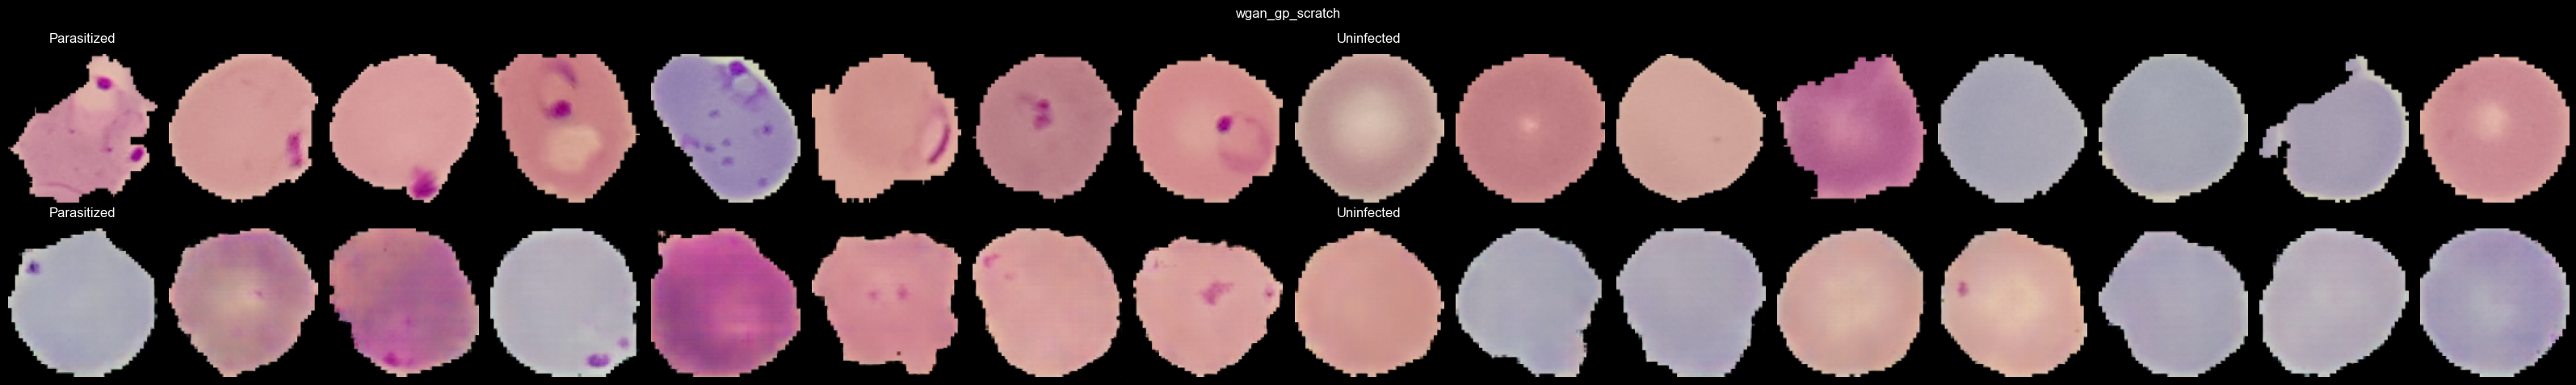

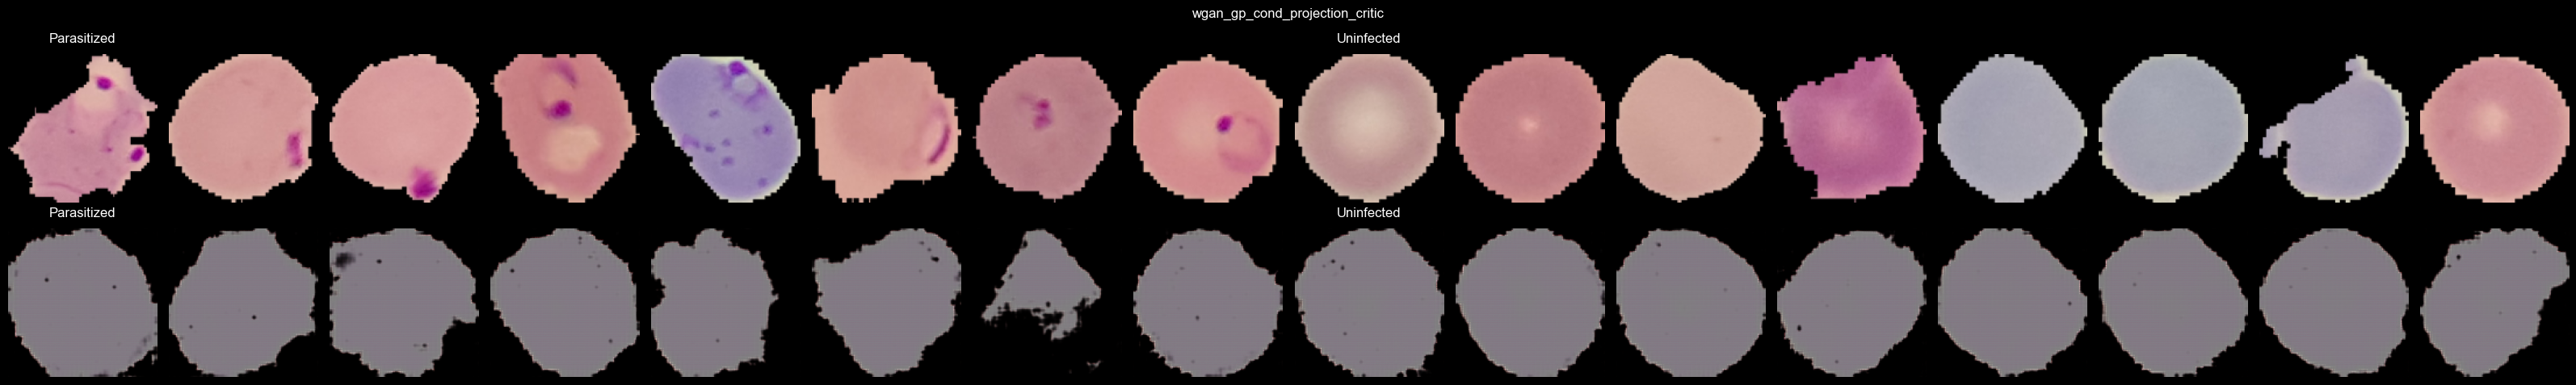

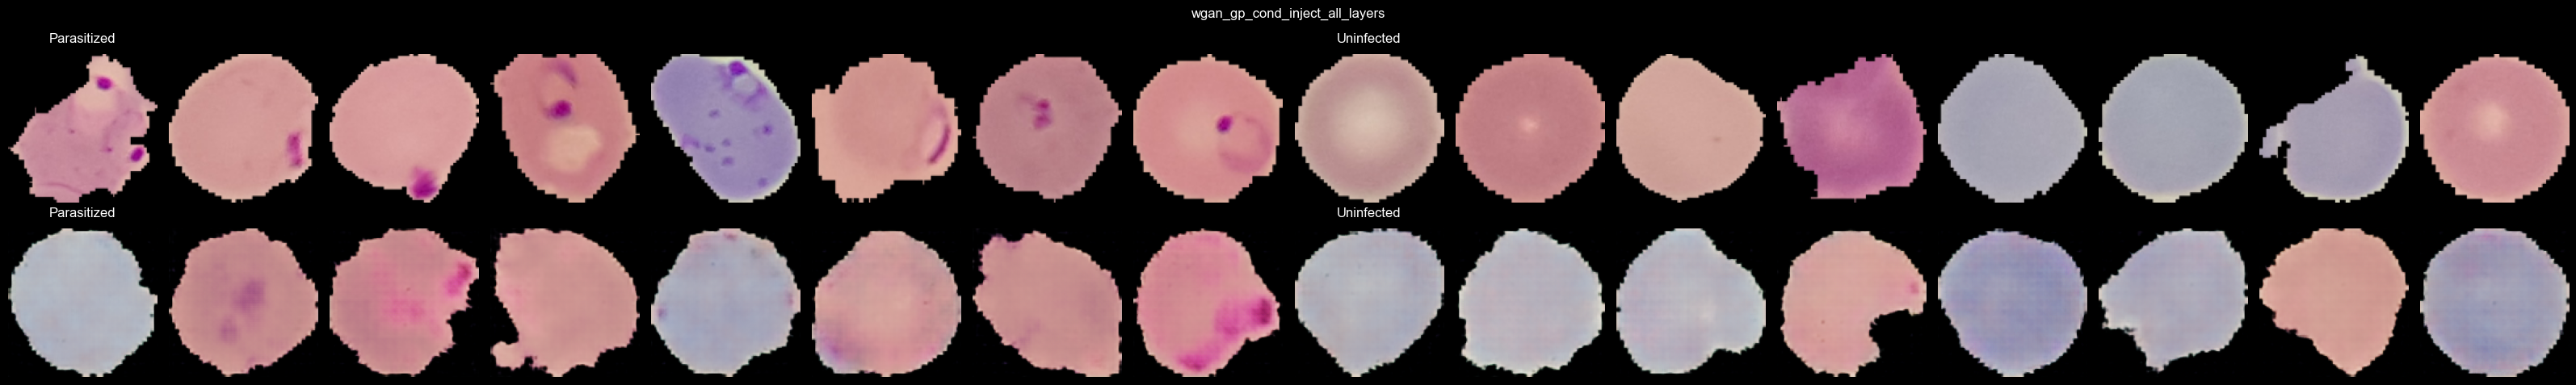

In [31]:
def sample_real_pair(class_name, num_images=8, seed=42):
    rng = random.Random(seed)
    candidates = [p for p in paths[class_name] if load_rgb(p) is not None]
    if len(candidates) < num_images:
        raise ValueError(f'Not enough real images for class {class_name}: {len(candidates)} available')
    picks = rng.sample(candidates, num_images)
    images = []
    for path in picks:
        arr = load_preprocessed_image(path, target_size=TARGET_SIZE, normalize=False)
        if arr is not None:
            images.append(arr)
    return np.stack(images, axis=0)


def sample_generated_pair(run_name, class_name, num_images=8):
    generator, checkpoint, _ = load_latest_checkpoint_generator(run_name)
    latent_dim = checkpoint['config']['model']['latent_dim']
    seed = int(checkpoint['config'].get('seed', 42)) + 97 * GENERATED_CLASSES.index(class_name)
    noise_generator = torch.Generator(device=DEVICE)
    noise_generator.manual_seed(seed)
    noise = torch.randn(num_images, latent_dim, 1, 1, device=DEVICE, generator=noise_generator)
    labels = build_generation_labels(class_name, num_images, checkpoint, device=DEVICE)
    with torch.no_grad():
        samples = generator(noise, labels).detach().cpu()
    return denormalize_tensor(samples).permute(0, 2, 3, 1).numpy()


def draw_row(ax_row, images, title):
    ax_row[0].set_ylabel(title, rotation=0, labelpad=28, va='center')
    for col, ax in enumerate(ax_row):
        ax.imshow(images[col])
        ax.axis('off')


def show_real_vs_generated_table(run_name, num_images=8):
    classes = GENERATED_CLASSES
    fig, axes = plt.subplots(2, len(classes) * num_images, figsize=(2.0 * len(classes) * num_images, 5))
    if len(classes) == 1:
        axes = axes.reshape(2, -1)

    for class_idx, class_name in enumerate(classes):
        real_images = sample_real_pair(class_name, num_images=num_images, seed=42)
        generated_images = sample_generated_pair(run_name, class_name, num_images=num_images)
        start = class_idx * num_images
        end = start + num_images
        draw_row(axes[0, start:end], real_images, "Real" if class_idx == 0 else "")
        draw_row(axes[1, start:end], generated_images, "GAN" if class_idx == 0 else "")
        axes[0, start].set_title(class_name, pad=10)
        axes[1, start].set_title(class_name, pad=10)

    fig.suptitle(run_name)
    plt.tight_layout()
    plt.show()


for run_name in WGAN_RUNS:
    show_real_vs_generated_table(run_name, num_images=8)


## 17. KID score pre vybrane WGANy

Tato bunka pocita KID podla logiky z `kid_score.py` z repa `abdulfatir/gan-metrics-pytorch`. Pocita sa len pre `wgan_gp_scratch` a `wgan_gp_cond_inject_all_layers`, a pre obe triedy samostatne.

In [33]:
import os
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics.pairwise import polynomial_kernel
from torchvision.models import Inception_V3_Weights, inception_v3
from torchvision.models.feature_extraction import create_feature_extractor

KID_RUNS = ['wgan_gp_scratch', 'wgan_gp_cond_inject_all_layers']
KID_CLASSES = GENERATED_CLASSES
KID_ROOT = Path('artifacts/kid_repo_style')
KID_ROOT.mkdir(parents=True, exist_ok=True)


def build_kid_extractor():
    weights = Inception_V3_Weights.DEFAULT
    model = inception_v3(weights=weights)
    model.eval().to(DEVICE)
    return create_feature_extractor(model, return_nodes={'avgpool': 'features'})


def images_to_chw_numpy(image_paths):
    arrays = []
    for path in image_paths:
        arr = load_preprocessed_image(path, target_size=TARGET_SIZE, normalize=True)
        if arr is not None:
            arrays.append(arr.transpose(2, 0, 1))
    if not arrays:
        raise ValueError('No valid images found')
    return np.stack(arrays, axis=0).astype(np.float32)


def load_fake_image_paths(run_name, class_name):
    fake_dir = GENERATED_1000_ROOT / run_name / class_name
    if not fake_dir.exists():
        raise FileNotFoundError(f'Missing generated directory: {fake_dir}')
    return sorted(p for p in fake_dir.glob('*.png') if p.name != 'preview_100.png')


def save_kid_npy_sets(run_name, class_name):
    real_paths = [p for p in paths[class_name] if p.suffix.lower() in VALID_EXTENSIONS and load_rgb(p) is not None]
    fake_paths = load_fake_image_paths(run_name, class_name)

    run_dir = KID_ROOT / run_name / class_name
    run_dir.mkdir(parents=True, exist_ok=True)

    real_npy = images_to_chw_numpy(real_paths)
    fake_npy = images_to_chw_numpy(fake_paths)

    real_path = run_dir / 'real.npy'
    fake_path = run_dir / 'fake.npy'
    np.save(real_path, real_npy)
    np.save(fake_path, fake_npy)
    return real_path, fake_path


def get_activations(files, model, batch_size=50, dims=2048, cuda=False):
    model.eval()
    if len(files) % batch_size != 0:
        print('Warning: number of images is not a multiple of the batch size. The last batch will be smaller.')
    if batch_size > len(files):
        batch_size = len(files)
    n_batches = (len(files) + batch_size - 1) // batch_size
    pred_arr = np.empty((len(files), dims), dtype=np.float32)
    device = next(model.parameters()).device

    for i in range(n_batches):
        start = i * batch_size
        end = min(start + batch_size, len(files))
        images = np.copy(files[start:end]) + 1.0
        images /= 2.0
        batch = torch.from_numpy(images).float().to(device)
        batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
        with torch.no_grad():
            pred = model(batch)['features']
        if pred.shape[2] != 1 or pred.shape[3] != 1:
            pred = F.adaptive_avg_pool2d(pred, output_size=(1, 1))
        pred_arr[start:end] = pred.cpu().numpy().reshape(end - start, -1)
    return pred_arr


def _sqn(arr):
    flat = np.ravel(arr)
    return flat.dot(flat)


def polynomial_mmd_averages(codes_g, codes_r, n_subsets=100, subset_size=1000, ret_var=True, **kernel_args):
    m = min(codes_g.shape[0], codes_r.shape[0])
    mmds = np.zeros(n_subsets, dtype=np.float64)
    vars = np.zeros(n_subsets, dtype=np.float64) if ret_var else None
    for i in range(n_subsets):
        g = codes_g[np.random.choice(len(codes_g), subset_size, replace=False)]
        r = codes_r[np.random.choice(len(codes_r), subset_size, replace=False)]
        o = polynomial_mmd(g, r, **kernel_args, var_at_m=m, ret_var=ret_var)
        if ret_var:
            mmds[i], vars[i] = o
        else:
            mmds[i] = o
    return (mmds, vars) if ret_var else mmds


def polynomial_mmd(codes_g, codes_r, degree=3, gamma=None, coef0=1, var_at_m=None, ret_var=True):
    X = codes_g
    Y = codes_r
    K_XX = polynomial_kernel(X, degree=degree, gamma=gamma, coef0=coef0)
    K_YY = polynomial_kernel(Y, degree=degree, gamma=gamma, coef0=coef0)
    K_XY = polynomial_kernel(X, Y, degree=degree, gamma=gamma, coef0=coef0)
    return _mmd2_and_variance(K_XX, K_XY, K_YY, var_at_m=var_at_m, ret_var=ret_var)


def _mmd2_and_variance(K_XX, K_XY, K_YY, unit_diagonal=False, mmd_est='unbiased', var_at_m=None, ret_var=True):
    m = K_XX.shape[0]
    if var_at_m is None:
        var_at_m = m
    if unit_diagonal:
        diag_X = diag_Y = 1
        sum_diag_X = sum_diag_Y = m
        sum_diag2_X = sum_diag2_Y = m
    else:
        diag_X = np.diagonal(K_XX)
        diag_Y = np.diagonal(K_YY)
        sum_diag_X = diag_X.sum()
        sum_diag_Y = diag_Y.sum()
        sum_diag2_X = _sqn(diag_X)
        sum_diag2_Y = _sqn(diag_Y)

    Kt_XX_sums = K_XX.sum(axis=1) - diag_X
    Kt_YY_sums = K_YY.sum(axis=1) - diag_Y
    K_XY_sums_0 = K_XY.sum(axis=0)
    K_XY_sums_1 = K_XY.sum(axis=1)

    Kt_XX_sum = Kt_XX_sums.sum()
    Kt_YY_sum = Kt_YY_sums.sum()
    K_XY_sum = K_XY_sums_0.sum()

    if mmd_est == 'biased':
        mmd2 = ((Kt_XX_sum + sum_diag_X) / (m * m) + (Kt_YY_sum + sum_diag_Y) / (m * m) - 2 * K_XY_sum / (m * m))
    else:
        mmd2 = (Kt_XX_sum + Kt_YY_sum) / (m * (m - 1))
        if mmd_est == 'unbiased':
            mmd2 -= 2 * K_XY_sum / (m * m)
        else:
            mmd2 -= 2 * (K_XY_sum - np.trace(K_XY)) / (m * (m - 1))

    if not ret_var:
        return mmd2

    Kt_XX_2_sum = _sqn(K_XX) - sum_diag2_X
    Kt_YY_2_sum = _sqn(K_YY) - sum_diag2_Y
    K_XY_2_sum = _sqn(K_XY)
    dot_XX_XY = Kt_XX_sums.dot(K_XY_sums_1)
    dot_YY_YX = Kt_YY_sums.dot(K_XY_sums_0)
    m1 = m - 1
    m2 = m - 2
    zeta1_est = (1 / (m * m1 * m2) * (_sqn(Kt_XX_sums) - Kt_XX_2_sum + _sqn(Kt_YY_sums) - Kt_YY_2_sum) - 1 / (m * m1)**2 * (Kt_XX_sum**2 + Kt_YY_sum**2) + 1 / (m * m * m1) * (_sqn(K_XY_sums_1) + _sqn(K_XY_sums_0) - 2 * K_XY_2_sum) - 2 / m**4 * K_XY_sum**2 - 2 / (m * m * m1) * (dot_XX_XY + dot_YY_YX) + 2 / (m**3 * m1) * (Kt_XX_sum + Kt_YY_sum) * K_XY_sum)
    zeta2_est = (1 / (m * m1) * (Kt_XX_2_sum + Kt_YY_2_sum) - 1 / (m * m1)**2 * (Kt_XX_sum**2 + Kt_YY_sum**2) + 2 / (m * m) * K_XY_2_sum - 2 / m**4 * K_XY_sum**2 - 4 / (m * m * m1) * (dot_XX_XY + dot_YY_YX) + 4 / (m**3 * m1) * (Kt_XX_sum + Kt_YY_sum) * K_XY_sum)
    var_est = (4 * (var_at_m - 2) / (var_at_m * (var_at_m - 1)) * zeta1_est + 2 / (var_at_m * (var_at_m - 1)) * zeta2_est)
    return mmd2, var_est


def calculate_kid_for_run_and_class(run_name, class_name):
    real_path, fake_path = save_kid_npy_sets(run_name, class_name)
    real_npy = np.load(real_path)
    fake_npy = np.load(fake_path)
    extractor = build_kid_extractor()
    act_true = get_activations(real_npy, extractor, batch_size=50, dims=2048, cuda=DEVICE.type == 'cuda')
    act_fake = get_activations(fake_npy, extractor, batch_size=50, dims=2048, cuda=DEVICE.type == 'cuda')
    kid_values = polynomial_mmd_averages(act_true, act_fake, n_subsets=100, subset_size=1000, ret_var=True, degree=3, gamma=None, coef0=1)
    return {
        'run_name': run_name,
        'class_name': class_name,
        'real_npy': str(real_path),
        'fake_npy': str(fake_path),
        'kid_mean': float(kid_values[0].mean()),
        'kid_std': float(kid_values[0].std()),
        'num_real': int(real_npy.shape[0]),
        'num_fake': int(fake_npy.shape[0]),
    }

kid_rows = []
for run_name in KID_RUNS:
    for class_name in KID_CLASSES:
        kid_rows.append(calculate_kid_for_run_and_class(run_name, class_name))

kid_df = pd.DataFrame(kid_rows)
kid_df


/Users/romankosik/PycharmProjects/Neuronove_siete/.venv/lib/python3.13/site-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


/Users/romankosik/PycharmProjects/Neuronove_siete/.venv/lib/python3.13/site-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


/Users/romankosik/PycharmProjects/Neuronove_siete/.venv/lib/python3.13/site-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


,run_name,class_name,real_npy,fake_npy,kid_mean,kid_std,num_real,num_fake
0,wgan_gp_scratch,Parasitized,artifacts/kid_repo_style/wgan_gp_scratch/Paras...,artifacts/kid_repo_style/wgan_gp_scratch/Paras...,0.015684,0.000816,13779,1000
1,wgan_gp_scratch,Uninfected,artifacts/kid_repo_style/wgan_gp_scratch/Uninf...,artifacts/kid_repo_style/wgan_gp_scratch/Uninf...,0.008270,0.000446,13779,1000
2,wgan_gp_cond_inject_all_layers,Parasitized,artifacts/kid_repo_style/wgan_gp_cond_inject_a...,artifacts/kid_repo_style/wgan_gp_cond_inject_a...,0.094880,0.001685,13779,1000
3,wgan_gp_cond_inject_all_layers,Uninfected,artifacts/kid_repo_style/wgan_gp_cond_inject_a...,artifacts/kid_repo_style/wgan_gp_cond_inject_a...,0.080628,0.001366,13779,1000


## 18. Mini quiz: real alebo GAN?

Najprv su len dvojice bez odpovede. Snaz sa tipnut, ktory obrazok je realny a ktory je z GANu.

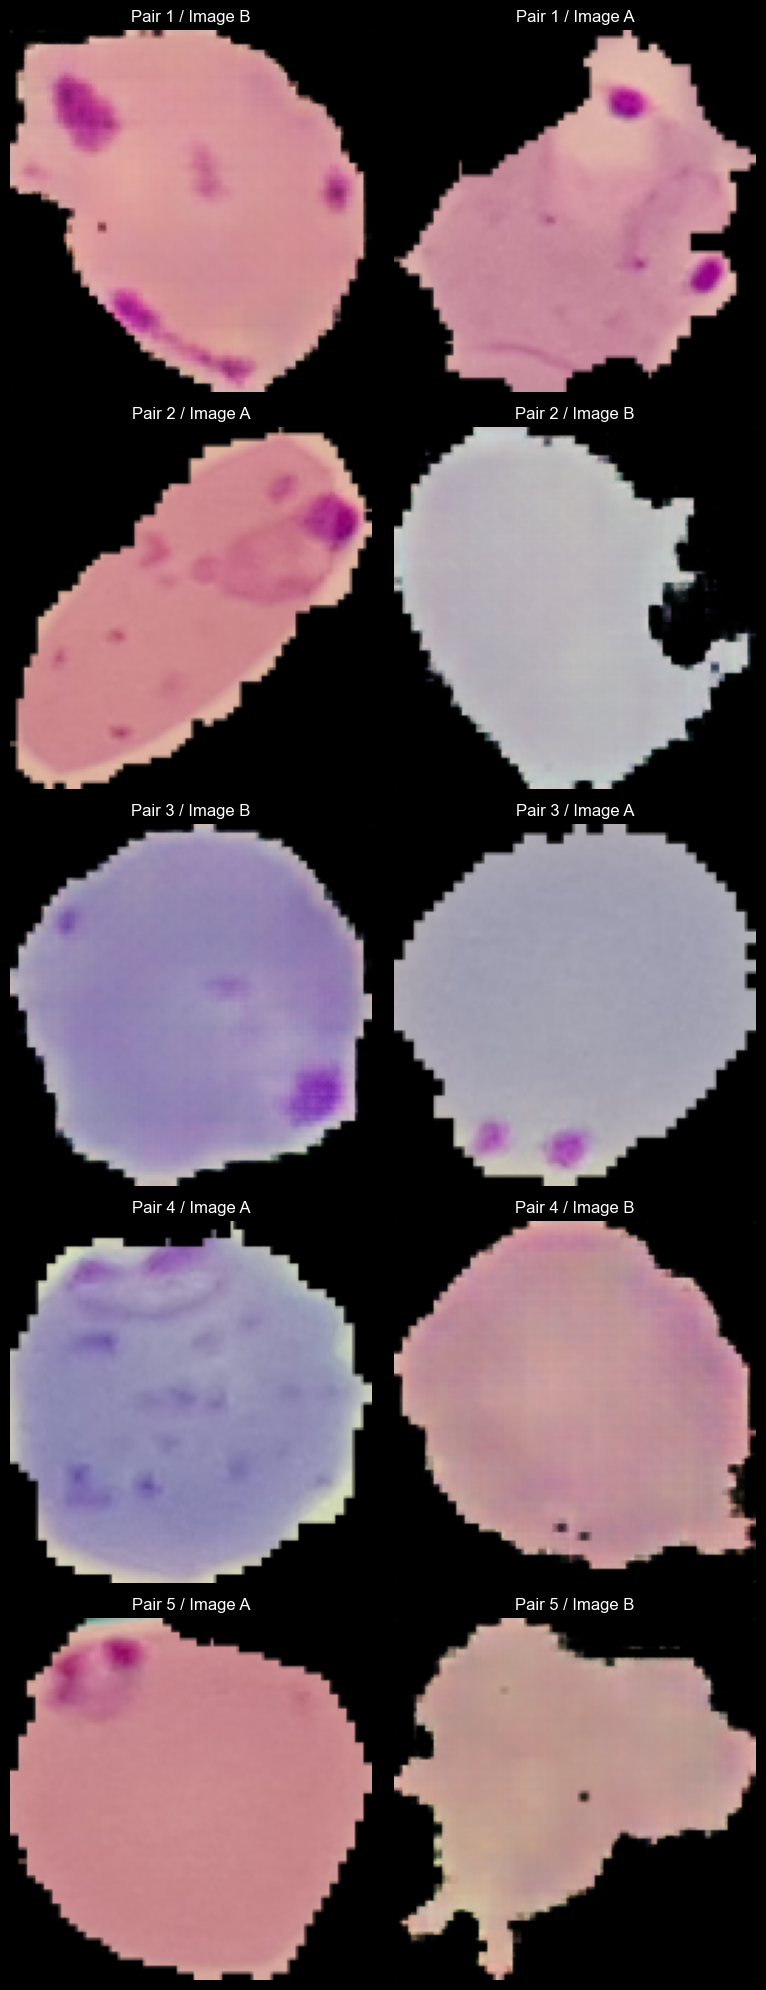

In [35]:
QUIZ_RUN = "wgan_gp_scratch"
QUIZ_CLASS = "Parasitized"
QUIZ_PAIRS = 5

def make_quiz_pair(run_name=QUIZ_RUN, class_name=QUIZ_CLASS, seed=42):
    rng = random.Random(seed)
    real_candidates = [p for p in paths[class_name] if load_rgb(p) is not None]
    real_path = rng.choice(real_candidates)

    generator, checkpoint, _ = load_latest_checkpoint_generator(run_name)
    latent_dim = checkpoint['config']['model']['latent_dim']
    noise_generator = torch.Generator(device=DEVICE)
    noise_generator.manual_seed(seed + 123)
    noise = torch.randn(1, latent_dim, 1, 1, device=DEVICE, generator=noise_generator)
    labels = build_generation_labels(class_name, 1, checkpoint, device=DEVICE)
    with torch.no_grad():
        fake = generator(noise, labels).detach().cpu()
    fake_img = denormalize_tensor(fake)[0].permute(1, 2, 0).numpy()

    real_img = load_preprocessed_image(real_path, target_size=TARGET_SIZE, normalize=False)
    pair = [("Image A", real_img), ("Image B", fake_img)]
    rng.shuffle(pair)
    answer = "A" if pair[0][0] == "Image A" else "B"
    return pair, answer


quiz_answers = []
fig, axes = plt.subplots(QUIZ_PAIRS, 2, figsize=(8, 4 * QUIZ_PAIRS))
if QUIZ_PAIRS == 1:
    axes = np.array([axes])

for row in range(QUIZ_PAIRS):
    pair, answer = make_quiz_pair(seed=42 + row)
    quiz_answers.append(answer)
    for col, (label, image) in enumerate(pair):
        ax = axes[row, col]
        ax.imshow(image)
        ax.axis('off')
        ax.set_title(f'Pair {row + 1} / {label}', fontsize=12)

plt.tight_layout()
plt.show()

# answers are stored in quiz_answers, but not printed here


## 19. Riesenie quizu

In [36]:
pd.DataFrame({
    "pair": [f"Pair {i + 1}" for i in range(len(quiz_answers))],
    "correct_image": quiz_answers,
})


,pair,correct_image
0,Pair 1,B
1,Pair 2,A
2,Pair 3,B
3,Pair 4,A
4,Pair 5,A
